## Feedback 2 - Juan Manuel

### Ejercicio 1: Construcción de una red neuronal LSTM con Keras

1. Preprocesar un conjunto de datos de series temporales (como precios de acciones, datos de
temperatura u otra secuencia numérica).

In [2]:
# Importar las librerías necesarias y cargar el conjunto de datos.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import kagglehub
from kagglehub import KaggleDatasetAdapter
from keras.layers import Dense, LSTM, Dropout, Input
from keras.models import Sequential
from keras.callbacks import EarlyStopping

# Path al fichero
file_path = "TSLA.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "varpit94/tesla-stock-data-updated-till-28jun2021",
  file_path,
)

# Si lo que me devuelve la query es una lista, el primer elemento es el Dataframe
if isinstance(df, list):
    df = df[0]

print("Columnas disponibles:", df.columns)

# Me quedo solo con el precio de cierre y lo reestructuro para que sea una matriz 2D
data = df['Close'].values.reshape(-1, 1)

print("First 5 records:", df.head())

print("Numero total de campos:", data.shape)


Columnas disponibles: Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')
First 5 records:          Date   Open   High    Low  Close  Adj Close    Volume
0  2010-06-29  3.800  5.000  3.508  4.778      4.778  93831500
1  2010-06-30  5.158  6.084  4.660  4.766      4.766  85935500
2  2010-07-01  5.000  5.184  4.054  4.392      4.392  41094000
3  2010-07-02  4.600  4.620  3.742  3.840      3.840  25699000
4  2010-07-06  4.000  4.000  3.166  3.222      3.222  34334500
Numero total de campos: (2956, 1)


In [3]:
# Preprocesar los datos: Normalizarlos y dividirlos en conjuntos de entrenamiento y prueba.
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Defino cuántos días voy a mirar hacia atrás
ventana_tiempo = 60

# Calculo el número de datos de entrenamiento (80% del total)
train_size = int(len(scaled_data) * 0.8)

# Creo el conjunto de entrenamiento
train_data = scaled_data[0:train_size, :]

# Creo el conjunto de prueba empezando desde donde termina el train menos 60
# para ofrecer contexto al conjunto de prueba
test_data = scaled_data[train_size - ventana_tiempo:, :]

print("Tamaño del conjunto de entrenamiento:", train_data.shape)
print("Tamaño del conjunto de prueba:", test_data.shape)


Tamaño del conjunto de entrenamiento: (2364, 1)
Tamaño del conjunto de prueba: (652, 1)


In [4]:
# Reestructurar los datos al formato de entrada requerido para LSTM: [muestras, pasos de tiempo, características]
def dataset_3D(data, ventana):
    X, y = [], []
    # Empiezo en 60 porque necesito 60 datos previos para predecir el siguiente
    for i in range(ventana, len(data)):
        # Tomo los últimos 60 datos como entrada y el siguiente como salida
        X.append(data[i - ventana:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = dataset_3D(train_data, ventana_tiempo)
X_test, y_test = dataset_3D(test_data, ventana_tiempo)

# Hago un reshape para que tenga la forma [muestras, pasos de tiempo, características]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"Forma de X_train para la LSTM: {X_train.shape}")
print(f"Forma de X_test para la LSTM:  {X_test.shape}")


Forma de X_train para la LSTM: (2304, 60, 1)
Forma de X_test para la LSTM:  (592, 60, 1)


2. Crear un modelo LSTM utilizando Keras.

In [6]:
# Definir un modelo LSTM utilizando la clase Sequential de Keras.
regressor = Sequential()

regressor.add(Input(shape=(X_train.shape[1], 1)))

regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))

regressor.add(Dense(units=1))  # Capa de salida

regressor.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Compilar el modelo con una función de pérdida y un optimizador adecuado.
regressor.compile(optimizer='adam', loss='mse', metrics=["mean_absolute_error"])


3. Entrenar el modelo con los datos de entrenamiento.

In [8]:
callbacks = [EarlyStopping(monitor= 'loss', patience= 10 , restore_best_weights= True)]
# Entrenar el modelo con los datos de entrenamiento.
history = regressor.fit(X_train, y_train, 
            epochs=50, 
            batch_size=32,
            validation_data=(X_test, y_test),
            verbose=1)


Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 9.3429e-05 - mean_absolute_error: 0.0067 - val_loss: 0.0156 - val_mean_absolute_error: 0.0923
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 2.2383e-05 - mean_absolute_error: 0.0037 - val_loss: 0.0128 - val_mean_absolute_error: 0.0816
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1.9887e-05 - mean_absolute_error: 0.0035 - val_loss: 0.0134 - val_mean_absolute_error: 0.0852
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1.6347e-05 - mean_absolute_error: 0.0031 - val_loss: 0.0131 - val_mean_absolute_error: 0.0845
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1.6502e-05 - mean_absolute_error: 0.0032 - val_loss: 0.0145 - val_mean_absolute_error: 0.0901
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1.5257e-05 - mean_absolute_error: 0.0030 - val_loss: 0.0157 - val_mean_absolute_error: 0.0948
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1.4161e-05 - mean_absol

4. Evaluar el rendimiento del modelo en los datos de prueba.

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


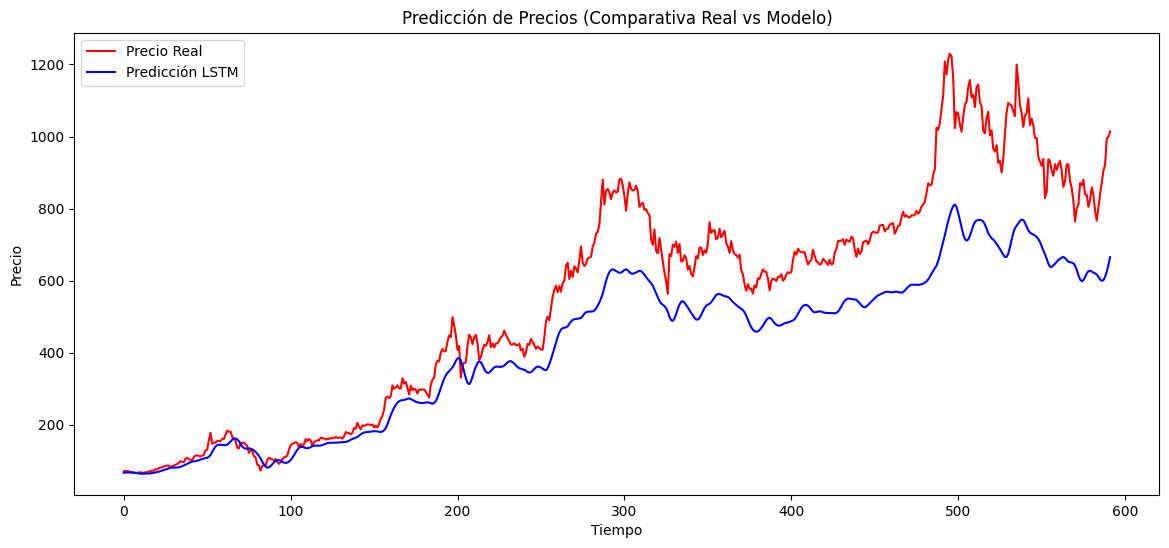

In [9]:
# Evaluo el rendimiento del modelo y visualizo los resultados.
predictions = regressor.predict(X_test)

# Invierto la normalización
predictions_real = scaler.inverse_transform(predictions)
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))

# Visualizo el resultado final
plt.figure(figsize=(14, 6))
plt.plot(y_test_real, color='red', label='Precio Real')
plt.plot(predictions_real, color='blue', label='Predicción LSTM')
plt.title('Predicción de Precios (Comparativa Real vs Modelo)')
plt.xlabel('Tiempo')
plt.ylabel('Precio')
plt.legend()
plt.show()

5. Visualizar la pérdida a lo largo de las epocs y realizar predicciones.

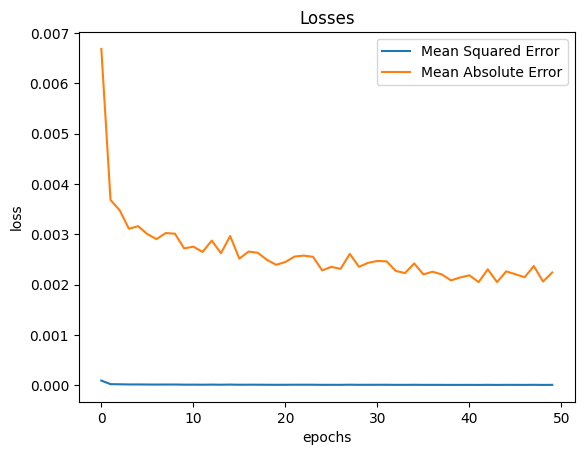

In [10]:
plt.plot(history.history["loss"])
plt.plot(history.history["mean_absolute_error"])
plt.legend(['Mean Squared Error','Mean Absolute Error'])
plt.title("Losses")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()


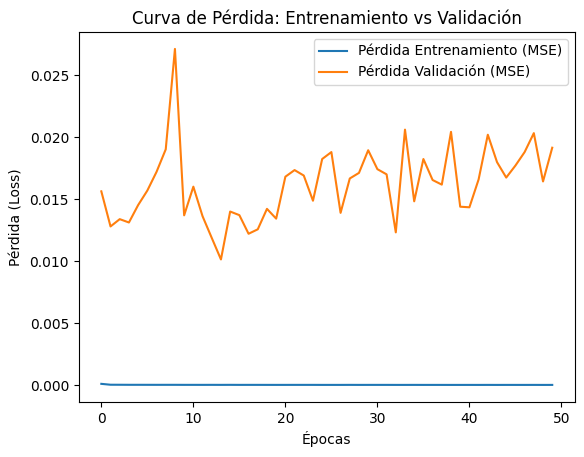

In [11]:
plt.plot(history.history["loss"], label='Pérdida Entrenamiento (MSE)')
plt.plot(history.history["val_loss"], label='Pérdida Validación (MSE)')

plt.title("Curva de Pérdida: Entrenamiento vs Validación")
plt.xlabel("Épocas")
plt.ylabel("Pérdida (Loss)")
plt.legend()
plt.show()

### Ejercicio 2: Construcción de una Red Neuronal Convolucional (CNN) para Clasificación de Imágenes usando Keras

Preparación del Conjunto de Datos

In [12]:
# Cargo el conjunto de datos CIFAR-10
import tensorflow as tf
from keras.datasets import cifar10
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

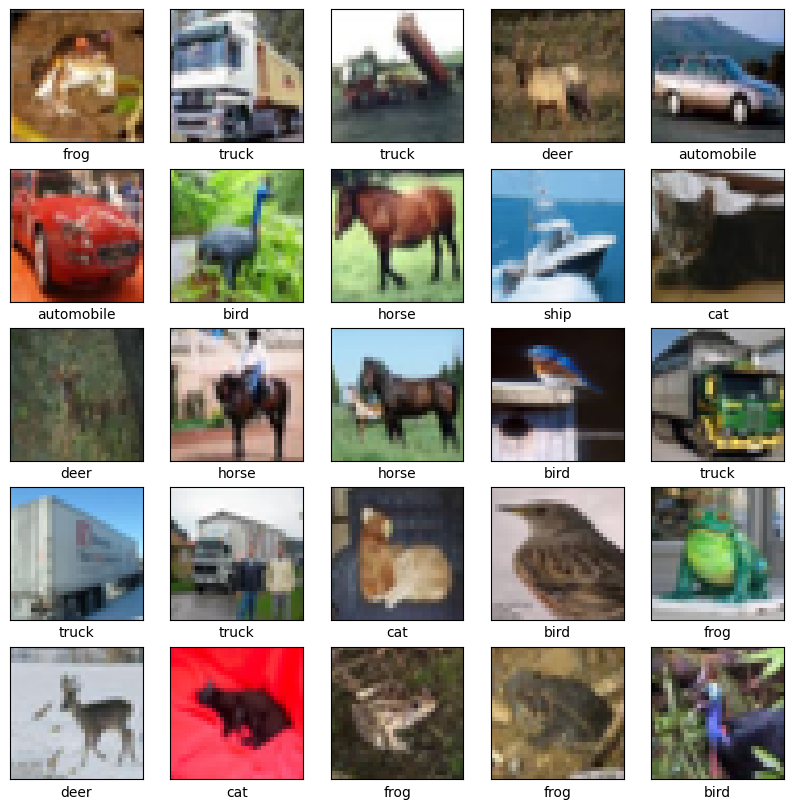

In [13]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Muestro imagenes para verificar que se cargó bien
plt.figure(figsize=(10,10))
# Matriz 5x5 de representación
for i in range(25):
    # Subplot de 5 filas y 5 columnas donde i+1 es la posición actual
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    # Saco la imagen i del conjunto de entrenamiento
    plt.imshow(train_images[i])
    # Imprimo la etiqueta correcta
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

In [14]:
# Normalizar los valores de píxeles a un rango de 0 a 1
train_images, test_images = train_images / 255.0, test_images / 255.0

# Convierto las etiquetas a one-hot encoding
etiquetas_train = to_categorical(train_labels, num_classes=10)
etiquetas_test = to_categorical(test_labels, num_classes=10)

Arquitectura del Modelo

In [15]:
model = Sequential()

model.add(Input(shape=(32, 32, 3)))
# Extraigo las características de las imágenes con una capa inicial convolucional y de pooling

# Capa convolucional: 32 filtros, ventana de 3x3 con activación relu
model.add(Conv2D(32, (3, 3), activation='relu'))
# Capa de Maxpooling: Reduce la imagen a la mitad, toma el maximo de cada 2x2
model.add(MaxPooling2D(2, 2))

# Aumento el nivel de detalle con más filtros

# Aumento a 64 filtros para ver detalles más complejos
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(64, (3, 3), activation='relu'))

# Aplico flatten a los mapas de caracteristicas para obtener un array de una dimension con todas las características
model.add(Flatten())

# Capa densa fully connected para clasificar las imágenes
model.add(Dense(64, activation='relu'))

# Capa de salida con una neurona por clase y activación softmax para clasificacion multiclase con % de pertenencia
model.add(Dense(10, activation='softmax'))

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

Compilación del Modelo

In [16]:
# Se compila el modelo usando un optimizador Adam y la función de pérdida SparseCategoricalCrossentrpy, adecuada
# para problemas de clasificación multiclase.

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

# Entreno el modelo
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4450 - loss: 1.5208 - val_accuracy: 0.5572 - val_loss: 1.2464
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5880 - loss: 1.1624 - val_accuracy: 0.6163 - val_loss: 1.0720
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6461 - loss: 1.0122 - val_accuracy: 0.6536 - val_loss: 0.9903
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6764 - loss: 0.9219 - val_accuracy: 0.6634 - val_loss: 0.9709
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7051 - loss: 0.8426 - val_accuracy: 0.6756 - val_loss: 0.9316
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7229 - loss: 0.7906 - val_accuracy: 0.6778 - val_loss: 0.9366
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7419 - loss: 0.7395 - val_accuracy: 0.6855 - val_loss: 0.9145
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7549 - loss: 0.6996 - 

Evaluación del Modelo

313/313 - 0s - 1ms/step - accuracy: 0.6987 - loss: 0.9180


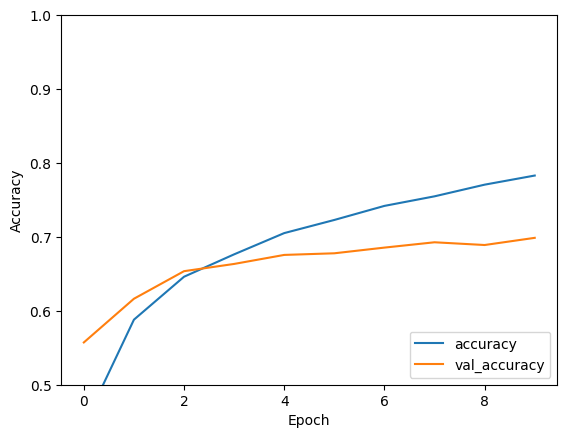

In [17]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)


In [18]:
print(test_acc)

0.6987000107765198
